# This nb audits every dataset used in this project

Inspects:
- Study Area
- Vector Datasets
- Satellite Images
- HMIS Datasets
- Census Datasets
- Animal Husbandry Dataset

Output:
- Reference Map
- Metadata Tables

In [1]:
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from src.config import *
from src.io import *
from src.metadata import *
from src.plotting import *
from src.export import *
from src.utils import *

In [2]:
print_header("OneHealth Environmental Monitoring - UTTARAKHAND\nDATASET AUDIT")
print()
print(f"Project Root : {ROOT}")
print(f"Raw Data     : {RAW}")
print(f"Processed    : {PROCESSED}")
print()

OneHealth Environmental Monitoring - UTTARAKHAND
DATASET AUDIT

Project Root : /Users/abhaypratap/OneHealth-Env-Monitoring-Uttarakhand
Raw Data     : /Users/abhaypratap/OneHealth-Env-Monitoring-Uttarakhand/data/raw
Processed    : /Users/abhaypratap/OneHealth-Env-Monitoring-Uttarakhand/data/processed



In [3]:
print_header("Dataset Availability")

datasets = {
    "District Boundary": load_district_boundary(),
    "Subdistrict Boundary": load_subdistrict_boundary(),
    "Satellite Years": list_satellite_years(),
    "HMIS": get_hmis_files(),
    "Census": get_census_files(),
    "Animal Husbandry": get_livestock_file(),
}

for name, value in datasets.items():
    if value is None:
        print(f"x {name}")

    elif isinstance(value, list):
        print(f"✔ {name}: {len(value)}")

    else:
        print(f"✔ {name}")

separator()

Dataset Availability
✔ District Boundary
✔ Subdistrict Boundary
✔ Satellite Years: 3
✔ HMIS: 3
✔ Census: 3
✔ Animal Husbandry
------------------------------------------------------------


In [4]:
districts = load_district_boundary()

print_metadata(
    get_vector_metadata(districts)
)

Dataset Type: Vector
Features: 810
Columns: ['OBJECTID', 'STATE_UT', 'STATE_LGD', 'DISTRICT', 'DIST_LGD', 'REMARKS', 'Shape_Leng', 'Shape_Area', 'geometry']
Geometry: MultiPolygon
CRS: PROJCS["LCC_WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",24],PARAMETER["central_meridian",80],PARAMETER["standard_parallel_1",12.472944],PARAMETER["standard_parallel_2",35.172806],PARAMETER["false_easting",4000000],PARAMETER["false_northing",4000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Bounds: {'xmin': 2818364.2018000036, 'ymin': 2177526.775600001, 'xmax': 5679118.517200001, 'ymax': 5444563.2162999995}


In [5]:
taluks = load_subdistrict_boundary()

print_metadata(
    get_vector_metadata(taluks)
)

Dataset Type: Vector
Features: 6668
Columns: ['OBJECTID', 'STATE_UT', 'STATE_LGD', 'DISTRICT', 'DIST_LGD', 'SUB_DIST', 'SUBDIS_LGD', 'SUBDIS_TYP', 'REMARKS', 'Shape_Leng', 'Shape_Area', 'geometry']
Geometry: MultiPolygon
CRS: PROJCS["LCC_WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",24],PARAMETER["central_meridian",80],PARAMETER["standard_parallel_1",12.472944],PARAMETER["standard_parallel_2",35.172806],PARAMETER["false_easting",4000000],PARAMETER["false_northing",4000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Bounds: {'xmin': 2818364.2018000036, 'ymin': 2177526.775600001, 'xmax': 5575565.088299997, 'ymax': 5444563.2162999995}


In [6]:
study_districts = load_study_districts()
study_taluks = load_study_taluks()

print(f"Study Districts : {len(study_districts)}")
print(f"Study Taluks    : {len(study_taluks)}")

Study Districts : 3
Study Taluks    : 25


Saved /Users/abhaypratap/OneHealth-Env-Monitoring-Uttarakhand/maps/static/01_india_context.png


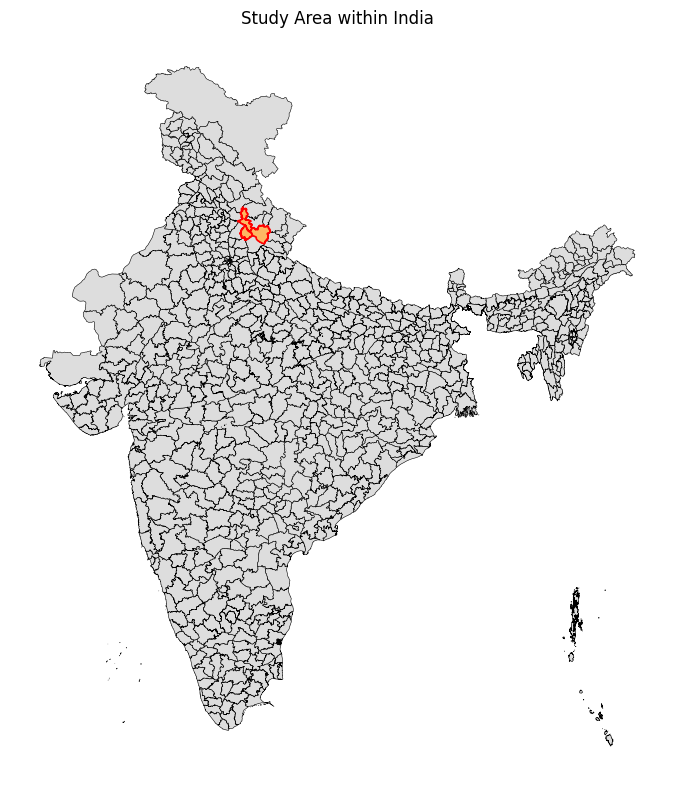

In [7]:
india = load_district_boundary()

fig, ax = plot_india_context(
    india,
    study_districts,
)

save_figure(
    fig,
    STATIC_MAPS / "01_india_context.png",
)

plt.show()

Saved /Users/abhaypratap/OneHealth-Env-Monitoring-Uttarakhand/maps/static/02_study_area.png


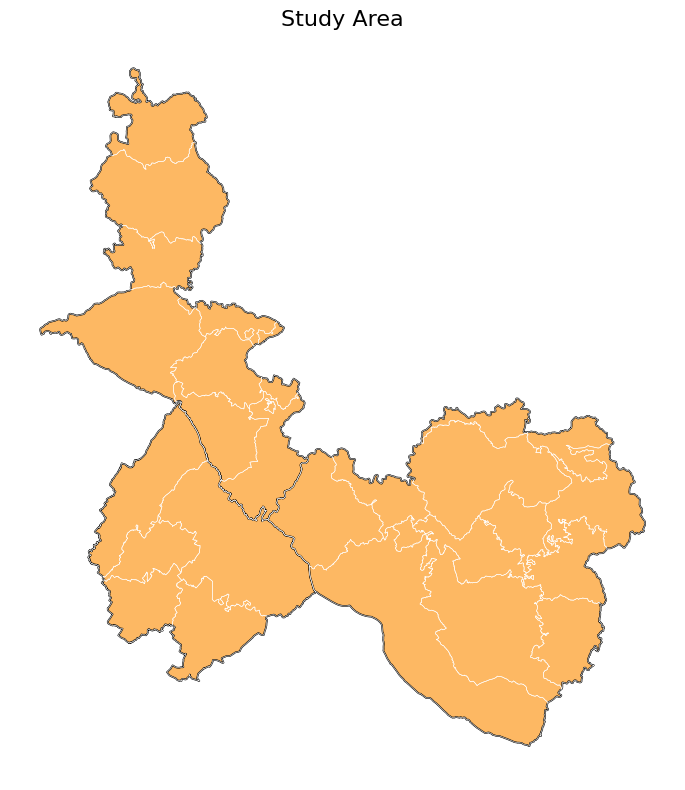

In [8]:
fig, ax = plot_boundaries(
    study_districts,
    study_taluks,
    title="Study Area",
)

save_figure(
    fig,
    STATIC_MAPS / "02_study_area.png",
)

plt.show()

In [9]:
export_geopackage(
    study_districts,
    PROCESSED / "study_districts.gpkg",
)

export_geopackage(
    study_taluks,
    PROCESSED / "study_taluks.gpkg",
)

Saved /Users/abhaypratap/OneHealth-Env-Monitoring-Uttarakhand/data/processed/study_districts.gpkg
Saved /Users/abhaypratap/OneHealth-Env-Monitoring-Uttarakhand/data/processed/study_taluks.gpkg


In [10]:
rows = []

for year in list_satellite_years():
    scenes = list_scenes(year)

    for scene in scenes:
        rows.append({
            "Year": year,
            "Scene": scene.name,
            "Bands": len(list_band_files(scene)),
            "Metadata": get_band_metadata(scene).exists(),
            "Accuracy Report": get_accuracy_report(scene).exists(),
        })

satellite_inventory = pd.DataFrame(rows)
satellite_inventory

,Year,Scene,Bands,Metadata,Accuracy Report
0,2016,Scene1,4,True,True
1,2016,Scene2,4,True,True
2,2016,Scene3,4,True,True
3,2022,Scene1,4,True,True
4,2022,Scene2,4,True,True
5,2022,Scene3,4,True,True
6,2025,Scene1,4,True,True
7,2025,Scene2,4,True,True
8,2025,Scene3,4,True,True


In [11]:
satellite_inventory.to_csv(
    REPORT / "tables" / "satellite_inventory.csv",
    index=False,
)

In [12]:
metadata = []

for year in list_satellite_years():
    for scene in list_scenes(year):
        for band in list_band_files(scene):

            with open_raster(band) as src:
                meta = get_raster_metadata(src)

                metadata.append({
                    "Year": year,
                    "Scene": scene.name,
                    "Band": band.name,
                    "CRS": meta["CRS"],
                    "Resolution": meta["Resolution"],
                    "Width": meta["Width"],
                    "Height": meta["Height"],
                })

raster_inventory = pd.DataFrame(metadata)
raster_inventory.head()

,Year,Scene,Band,CRS,Resolution,Width,Height
0,2016,Scene1,BAND2.tif,"PROJCS[""WGS 84 / UTM zone 44N"",GEOGCS[""WGS 84""...","(24.0, 24.0)",8080,7232
1,2016,Scene1,BAND3.tif,"PROJCS[""WGS 84 / UTM zone 44N"",GEOGCS[""WGS 84""...","(24.0, 24.0)",8080,7232
2,2016,Scene1,BAND4.tif,"PROJCS[""WGS 84 / UTM zone 44N"",GEOGCS[""WGS 84""...","(24.0, 24.0)",8080,7232
3,2016,Scene1,BAND5.tif,"PROJCS[""WGS 84 / UTM zone 44N"",GEOGCS[""WGS 84""...","(24.0, 24.0)",8080,7232
4,2016,Scene2,BAND2.tif,"PROJCS[""WGS 84 / UTM zone 43N"",GEOGCS[""WGS 84""...","(24.0, 24.0)",7666,7452


In [13]:
raster_inventory.to_csv(
    REPORT / "tables" / "raster_inventory.csv",
    index=False,
)

In [14]:
for file in get_hmis_files():
    print(file.name)

Dehradun.xlsx
Haridwar.xlsx
PauriGarhwal.xlsx


In [15]:
for file in get_census_files():
    print(file.name)

PCA_11_DDN.xlsx
PCA_11_GHW.xlsx
PCA_11_HDW.xlsx


In [16]:
print(get_livestock_file())

/Users/abhaypratap/OneHealth-Env-Monitoring-Uttarakhand/data/raw/livestock/Animal_Husbandry_2024.pdf


In [17]:
summary = pd.DataFrame({
    "Dataset": [
        "Study Districts",
        "District Boundary",
        "Study Subdistricts",
        "Subdistrict Boundary",
        "Satellite Scenes",
        "HMIS",
        "Census",
        "Animal Husbandry",
    ],
    
    "Count": [
        len(study_districts),
        len(districts),
        len(study_taluks),
        len(taluks),
        len(satellite_inventory),
        len(get_hmis_files()),
        len(get_census_files()),
        1,
    ],
})

summary

,Dataset,Count
0,Study Districts,3
1,District Boundary,810
2,Study Subdistricts,25
3,Subdistrict Boundary,6668
4,Satellite Scenes,9
5,HMIS,3
6,Census,3
7,Animal Husbandry,1


In [18]:
summary.to_csv(
    REPORT / "tables" / "dataset_summary.csv",
    index=False,
)

In [19]:
print_header("DATA DISCOVERY COMPLETED")
print()

print("Outputs Generated:")
print("- maps/static/01_india_context.png")
print("- maps/static/02_study_area.png")
print("- report/tables/dataset_summary.csv")
print("- report/tables/satellite_inventory.csv")
print("- report/tables/raster_inventory.csv")
print("- data/processed/study_districts.gpkg")
print("- data/processed/study_taluks.gpkg")

DATA DISCOVERY COMPLETED

Outputs Generated:
- maps/static/01_india_context.png
- maps/static/02_study_area.png
- report/tables/dataset_summary.csv
- report/tables/satellite_inventory.csv
- report/tables/raster_inventory.csv
- data/processed/study_districts.gpkg
- data/processed/study_taluks.gpkg
